# Divergence Token Evolution Across Multi-Hop Training

This notebook tracks how divergence tokens evolve across hops in the multi-hop preference experiment. It compares token counts, token positions, and correctness matrices across seeds and hops, then exports tables, plots, and a short markdown report.

## Configuration

Edit the parameters in the next cell to point the notebook at a different experiment directory, model, target preference, or hop list.

The notebook is written to be tolerant of both seed-specific hop folders and hop-level folders without a seed subdirectory.

In [1]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists() and (candidate / 'workspace').exists():
            return candidate
    return start

NOTEBOOK_PATH = Path.cwd().resolve()
REPO_ROOT = find_repo_root(NOTEBOOK_PATH)
NOTEBOOK_DIR = REPO_ROOT / 'notebooks' / 'div_points_analysis'
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path('/home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis')

EXP_DIR = REPO_ROOT / 'workspace' / 'multihop'
MODEL = 'gemma'
TARGET_PREFERENCE = 'raven'
SEEDS = [42]
# SEEDS = [42, 43, 44, 45, 46]
HOPS = ['hop0', 'hop1', 'hop2', 'hop3', 'hop4', 'hop5', 'hop6']

ANIMAL_TARGETS = ['panda', 'cat', 'dog', 'lion', 'penguin', 'dolphin', 'eagle', 'elephant', 'wolf', 'otter', 'raven', 'octopus']
TREE_TARGETS = ['oak', 'pine', 'sequoia', 'redwood', 'willow', 'birch', 'maple', 'banyan', 'bamboo', 'olive', 'mango', 'mangrove', 'baobab']

if TARGET_PREFERENCE in ANIMAL_TARGETS:
    CATEGORY = 'animal'
    TARGET_INDEX = ANIMAL_TARGETS.index(TARGET_PREFERENCE)
elif TARGET_PREFERENCE in TREE_TARGETS:
    CATEGORY = 'tree'
    TARGET_INDEX = TREE_TARGETS.index(TARGET_PREFERENCE)
else:
    CATEGORY = 'animal'
    TARGET_INDEX = None
    warnings.warn(f'Target preference {TARGET_PREFERENCE!r} was not found in the built-in lists. The notebook will still run, but target-indexed correctness checks will fall back to row 0.')

HOP_LABELS = {hop: f'Hop {idx}' for idx, hop in enumerate(HOPS)}
OUTPUT_DIR = NOTEBOOK_DIR / 'divergence_token_analysis'
PLOT_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Notebook cwd: {NOTEBOOK_PATH}')
print(f'Repo root: {REPO_ROOT}')
print(f'Experiment directory: {EXP_DIR.resolve()}')
print(f'Notebook output directory: {OUTPUT_DIR}')
print(f'Category: {CATEGORY} | Target index: {TARGET_INDEX}')

Notebook cwd: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis
Repo root: /home/abasso_aims_ac_za/divergence-tokens
Experiment directory: /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop
Notebook output directory: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis
Category: animal | Target index: 10


## Interpretation Guide

- `total_dpoints` counts all divergence tokens observed in a hop.
- `mean_dpoints_per_sample` shows how many divergence tokens a typical sample has. Rising values usually indicate stronger or earlier divergence.
- `mean_position` and `median_position` summarize where divergence tokens tend to appear inside the completion. Lower positions mean earlier divergence.
- `samples_with_0`, `samples_with_1`, `samples_with_2`, and `samples_with_3plus` describe how the per-sample distribution shifts across hops.
- Confidence intervals are interpreted in the usual way: if the 95 percent intervals do not overlap, that is strong evidence of a real shift, though not a formal hypothesis test by itself.
- In the correctness matrices, the target row corresponds to the target preference being checked against all counterfactual preferences. Higher target accuracy at decision points suggests that the divergence tokens align with the target preference more strongly.

In [3]:
def load_jsonl(path: Path | None) -> list:
    if path is None or not path.exists():
        return []
    records = []
    with path.open('r', encoding='utf-8') as handle:
        for line_number, line in enumerate(handle, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                warnings.warn(f'Could not parse JSON on line {line_number} in {path}: {exc}')
    return records

def resolve_data_file(exp_dir: Path, model: str, target: str, hop: str, seed: int, filename: str) -> Path | None:
    base = exp_dir / model / target
    candidates = []
    if hop:
        candidates.extend([
            base / hop / filename,
            base / hop / f'seed-{seed}' / filename,
        ])
    else:
        candidates.extend([
            base / f'seed-{seed}' / filename,
            base / filename,
        ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    warnings.warn(
        f'Missing file for hop={hop!r}, seed={seed}, filename={filename!r}. Tried: ' + ', '.join(str(candidate) for candidate in candidates)
    )
    return None

def safe_mean(values: list[float] | np.ndarray) -> float:
    array = np.asarray(values, dtype=float)
    array = array[np.isfinite(array)]
    if array.size == 0:
        return np.nan
    return float(array.mean())

def summarize_positions(positions: list[int]) -> dict:
    if not positions:
        return {
            'mean_position': np.nan,
            'median_position': np.nan,
            'std_position': np.nan,
            'min_position': np.nan,
            'max_position': np.nan,
        }
    array = np.asarray(positions, dtype=float)
    return {
        'mean_position': float(array.mean()),
        'median_position': float(np.median(array)),
        'std_position': float(array.std(ddof=1)) if array.size > 1 else 0.0,
        'min_position': float(array.min()),
        'max_position': float(array.max()),
    }

def compute_ci(values, confidence: float = 0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n == 0:
        return {
            'mean': np.nan,
            'margin_error': np.nan,
            'lower_bound': np.nan,
            'upper_bound': np.nan,
            'count': 0,
            'confidence': confidence,
        }
    mean = values.mean()
    if n == 1:
        margin_error = 0.0
    else:
        se = values.std(ddof=1) / np.sqrt(n)
        if n <= 30:
            t_critical = stats.t.ppf((1 + confidence) / 2, df=n - 1)
            margin_error = t_critical * se
        else:
            z_critical = stats.norm.ppf((1 + confidence) / 2)
            margin_error = z_critical * se
    return {
        'mean': float(mean),
        'margin_error': float(margin_error),
        'lower_bound': float(mean - margin_error),
        'upper_bound': float(mean + margin_error),
        'count': int(n),
        'confidence': confidence,
    }

def bucket_count(n_dpoints: int) -> str:
    if n_dpoints == 0:
        return '0'
    if n_dpoints == 1:
        return '1'
    if n_dpoints == 2:
        return '2'
    return '3plus'

def hop_name(hop: str) -> str:
    return HOP_LABELS.get(hop, hop or 'Hop 0')

def save_figure(fig, stem: str) -> list[Path]:
    png_path = PLOT_DIR / f'{stem}.png'
    pdf_path = PLOT_DIR / f'{stem}.pdf'
    fig.tight_layout()
    fig.savefig(png_path, dpi=200, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f'Saved figure: {png_path}')
    print(f'Saved figure: {pdf_path}')
    return [png_path, pdf_path]

def ci_overlap(a: dict, b: dict) -> bool:
    if not np.isfinite(a.get('lower_bound', np.nan)) or not np.isfinite(b.get('lower_bound', np.nan)):
        return False
    return not (a['upper_bound'] < b['lower_bound'] or b['upper_bound'] < a['lower_bound'])

In [4]:
def load_hop_seed_bundle(hop: str, seed: int):
    dpoints_path = resolve_data_file(EXP_DIR, MODEL, TARGET_PREFERENCE, hop, seed, 'filtered_dataset_dpoints_only.jsonl')
    matrices_path = resolve_data_file(EXP_DIR, MODEL, TARGET_PREFERENCE, hop, seed, 'filtered_dataset_correct_matrices.jsonl')

    dpoint_records = load_jsonl(dpoints_path)
    matrix_records = load_jsonl(matrices_path)

    if not dpoint_records:
        warnings.warn(f'No divergence-token records loaded for hop={hop!r}, seed={seed}.')
        return [], [], []

    if matrix_records and len(matrix_records) != len(dpoint_records):
        warnings.warn(
            f'File length mismatch for hop={hop!r}, seed={seed}: '
            f'{len(dpoint_records)} dpoint records vs {len(matrix_records)} matrix records.'
        )

    sample_rows = []
    position_rows = []
    matrix_rows = []

    for sample_index, record in enumerate(dpoint_records):
        decision_points = record.get('decision_points') or []
        if not isinstance(decision_points, list):
            decision_points = [decision_points]
        decision_points = [int(point) for point in decision_points if point is not None]
        pos_summary = summarize_positions(decision_points)
        n_dpoints = len(decision_points)
        bucket = bucket_count(n_dpoints)

        matrix = None
        target_row = None
        target_row_index = None
        if sample_index < len(matrix_records):
            matrix = np.asarray(matrix_records[sample_index], dtype=bool)
            if matrix.ndim == 2 and matrix.size > 0:
                target_row_index = TARGET_INDEX if TARGET_INDEX is not None and TARGET_INDEX < matrix.shape[0] else 0
                target_row = matrix[target_row_index]
            else:
                warnings.warn(f'Unexpected correctness-matrix shape for hop={hop!r}, seed={seed}, sample={sample_index}: {matrix.shape}')

        valid_positions = [point for point in decision_points if target_row is not None and 0 <= point < target_row.shape[0]]
        if len(valid_positions) != len(decision_points):
            warnings.warn(f'Some decision points were out of range for hop={hop!r}, seed={seed}, sample={sample_index}.')

        target_correct_at_dpoints = float(target_row[valid_positions].mean()) if valid_positions and target_row is not None else np.nan
        target_accuracy = float(target_row.mean()) if target_row is not None and target_row.size > 0 else np.nan
        matrix_density = float(matrix.mean()) if matrix is not None and matrix.size > 0 else np.nan

        sample_rows.append({
            'hop': hop,
            'hop_label': hop_name(hop),
            'hop_index': HOPS.index(hop),
            'seed': seed,
            'sample_index': sample_index,
            'prompt': record.get('prompt', ''),
            'n_dpoints': n_dpoints,
            'bucket': bucket,
            'decision_points': json.dumps(decision_points),
            'decision_points_count': n_dpoints,
            'mean_position': pos_summary['mean_position'],
            'median_position': pos_summary['median_position'],
            'std_position': pos_summary['std_position'],
            'min_position': pos_summary['min_position'],
            'max_position': pos_summary['max_position'],
            'target_correct_at_dpoints': target_correct_at_dpoints,
            'target_accuracy': target_accuracy,
            'matrix_density': matrix_density,
            'matrix_rows': int(matrix.shape[0]) if matrix is not None and matrix.ndim == 2 else np.nan,
            'matrix_cols': int(matrix.shape[1]) if matrix is not None and matrix.ndim == 2 else np.nan,
            'target_row_index': target_row_index,
        })

        for position in valid_positions:
            position_rows.append({
                'hop': hop,
                'hop_label': hop_name(hop),
                'hop_index': HOPS.index(hop),
                'seed': seed,
                'sample_index': sample_index,
                'position': int(position),
            })

        matrix_rows.append({
            'hop': hop,
            'hop_label': hop_name(hop),
            'hop_index': HOPS.index(hop),
            'seed': seed,
            'sample_index': sample_index,
            'n_dpoints': n_dpoints,
            'target_correct_at_dpoints': target_correct_at_dpoints,
            'target_accuracy': target_accuracy,
            'matrix_density': matrix_density,
        })

    return sample_rows, position_rows, matrix_rows

all_sample_rows = []
all_position_rows = []
all_matrix_rows = []
loaded_seed_map = {hop: [] for hop in HOPS}

print('Loading divergence-token data...')
for hop in HOPS:
    print()
    print(f'[{hop_name(hop)}]')
    for seed in SEEDS:
        print(f'  seed {seed}...')
        sample_rows, position_rows, matrix_rows = load_hop_seed_bundle(hop, seed)
        if sample_rows:
            loaded_seed_map[hop].append(seed)
        all_sample_rows.extend(sample_rows)
        all_position_rows.extend(position_rows)
        all_matrix_rows.extend(matrix_rows)

sample_df = pd.DataFrame(all_sample_rows)
position_df = pd.DataFrame(all_position_rows)
matrix_df = pd.DataFrame(all_matrix_rows)

if sample_df.empty:
    sample_df = pd.DataFrame(columns=['hop', 'hop_label', 'hop_index', 'seed', 'sample_index', 'prompt', 'n_dpoints', 'bucket', 'decision_points', 'decision_points_count', 'mean_position', 'median_position', 'std_position', 'min_position', 'max_position', 'target_correct_at_dpoints', 'target_accuracy', 'matrix_density', 'matrix_rows', 'matrix_cols', 'target_row_index'])
if position_df.empty:
    position_df = pd.DataFrame(columns=['hop', 'hop_label', 'hop_index', 'seed', 'sample_index', 'position'])
if matrix_df.empty:
    matrix_df = pd.DataFrame(columns=['hop', 'hop_label', 'hop_index', 'seed', 'sample_index', 'n_dpoints', 'target_correct_at_dpoints', 'target_accuracy', 'matrix_density'])

sample_df['prompt_occurrence'] = sample_df.groupby(['hop', 'seed', 'prompt']).cumcount() if not sample_df.empty else pd.Series(dtype=int)
sample_df['sample_key'] = sample_df.apply(lambda row: f"{row['seed']}::{row['prompt_occurrence']}::{row['prompt']}", axis=1) if not sample_df.empty else pd.Series(dtype=str)
sample_df['is_0'] = (sample_df['n_dpoints'] == 0).astype(int) if not sample_df.empty else pd.Series(dtype=int)
sample_df['is_1'] = (sample_df['n_dpoints'] == 1).astype(int) if not sample_df.empty else pd.Series(dtype=int)
sample_df['is_2'] = (sample_df['n_dpoints'] == 2).astype(int) if not sample_df.empty else pd.Series(dtype=int)
sample_df['is_3plus'] = (sample_df['n_dpoints'] >= 3).astype(int) if not sample_df.empty else pd.Series(dtype=int)

print(f'Loaded {len(sample_df)} sample rows, {len(position_df)} token-position rows, and {len(matrix_df)} correctness-matrix rows.')
for hop, seeds in loaded_seed_map.items():
    missing = [seed for seed in SEEDS if seed not in seeds]
    if missing:
        warnings.warn(f'Missing seeds for {hop_name(hop)}: {missing}')

token_counts_export = sample_df[[c for c in ['hop', 'hop_label', 'hop_index', 'seed', 'sample_index', 'prompt', 'prompt_occurrence', 'sample_key', 'n_dpoints', 'bucket', 'mean_position', 'median_position', 'std_position', 'min_position', 'max_position', 'target_correct_at_dpoints', 'target_accuracy', 'matrix_density'] if c in sample_df.columns]].copy()
counts_path = OUTPUT_DIR / 'token_counts_by_hop.csv'
token_counts_export.to_csv(counts_path, index=False)
print(f'Saved token count table to {counts_path}')

Loading divergence-token data...

[Hop 0]
  seed 42...



[Hop 1]
  seed 42...

[Hop 2]
  seed 42...

[Hop 3]
  seed 42...

[Hop 4]
  seed 42...

[Hop 5]
  seed 42...

[Hop 6]
  seed 42...
Loaded 39434 sample rows, 161276 token-position rows, and 39434 correctness-matrix rows.
Saved token count table to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/token_counts_by_hop.csv


In [5]:
def load_hop_seed_bundle(hop: str, seed: int):
    dpoints_path = resolve_data_file(EXP_DIR, MODEL, TARGET_PREFERENCE, hop, seed, 'filtered_dataset_dpoints_only.jsonl')
    matrices_path = resolve_data_file(EXP_DIR, MODEL, TARGET_PREFERENCE, hop, seed, 'filtered_dataset_correct_matrices.jsonl')

    dpoint_records = load_jsonl(dpoints_path)
    matrix_records = load_jsonl(matrices_path)

    if not dpoint_records:
        warnings.warn(f'No divergence-token records loaded for hop={hop!r}, seed={seed}.')
        return [], [], []

    if matrix_records and len(matrix_records) != len(dpoint_records):
        warnings.warn(
            f'File length mismatch for hop={hop!r}, seed={seed}: '
            f'{len(dpoint_records)} dpoint records vs {len(matrix_records)} matrix records.'
        )

    sample_rows = []
    position_rows = []
    matrix_rows = []

    for sample_index, record in enumerate(dpoint_records):
        decision_points = record.get('decision_points') or []
        if not isinstance(decision_points, list):
            decision_points = [decision_points]
        decision_points = [int(point) for point in decision_points if point is not None]
        pos_summary = summarize_positions(decision_points)
        n_dpoints = len(decision_points)
        bucket = bucket_count(n_dpoints)

        matrix = None
        target_row = None
        target_row_index = None
        if sample_index < len(matrix_records):
            matrix = np.asarray(matrix_records[sample_index], dtype=bool)
            if matrix.ndim == 2 and matrix.size > 0:
                target_row_index = TARGET_INDEX if TARGET_INDEX is not None and TARGET_INDEX < matrix.shape[0] else 0
                target_row = matrix[target_row_index]
            else:
                warnings.warn(f'Unexpected correctness-matrix shape for hop={hop!r}, seed={seed}, sample={sample_index}: {matrix.shape}')

        valid_positions = [point for point in decision_points if target_row is not None and 0 <= point < target_row.shape[0]]
        if len(valid_positions) != len(decision_points):
            warnings.warn(f'Some decision points were out of range for hop={hop!r}, seed={seed}, sample={sample_index}.')

        target_correct_at_dpoints = float(target_row[valid_positions].mean()) if valid_positions and target_row is not None else np.nan
        target_accuracy = float(target_row.mean()) if target_row is not None and target_row.size > 0 else np.nan
        matrix_density = float(matrix.mean()) if matrix is not None and matrix.size > 0 else np.nan

        sample_rows.append({
            'hop': hop,
            'hop_label': hop_name(hop),
            'hop_index': HOPS.index(hop),
            'seed': seed,
            'sample_index': sample_index,
            'prompt': record.get('prompt', ''),
            'n_dpoints': n_dpoints,
            'bucket': bucket,
            'decision_points': json.dumps(decision_points),
            'decision_points_count': n_dpoints,
            'mean_position': pos_summary['mean_position'],
            'median_position': pos_summary['median_position'],
            'std_position': pos_summary['std_position'],
            'min_position': pos_summary['min_position'],
            'max_position': pos_summary['max_position'],
            'target_correct_at_dpoints': target_correct_at_dpoints,
            'target_accuracy': target_accuracy,
            'matrix_density': matrix_density,
            'matrix_rows': int(matrix.shape[0]) if matrix is not None and matrix.ndim == 2 else np.nan,
            'matrix_cols': int(matrix.shape[1]) if matrix is not None and matrix.ndim == 2 else np.nan,
            'target_row_index': target_row_index,
        })

        for position in valid_positions:
            position_rows.append({
                'hop': hop,
                'hop_label': hop_name(hop),
                'hop_index': HOPS.index(hop),
                'seed': seed,
                'sample_index': sample_index,
                'position': int(position),
            })

        matrix_rows.append({
            'hop': hop,
            'hop_label': hop_name(hop),
            'hop_index': HOPS.index(hop),
            'seed': seed,
            'sample_index': sample_index,
            'n_dpoints': n_dpoints,
            'target_correct_at_dpoints': target_correct_at_dpoints,
            'target_accuracy': target_accuracy,
            'matrix_density': matrix_density,
        })

    return sample_rows, position_rows, matrix_rows

all_sample_rows = []
all_position_rows = []
all_matrix_rows = []
loaded_seed_map = {hop: [] for hop in HOPS}

print('Loading divergence-token data...')
for hop in HOPS:
    print()
    print(f'[{hop_name(hop)}]')
    for seed in SEEDS:
        print(f'  seed {seed}...')
        sample_rows, position_rows, matrix_rows = load_hop_seed_bundle(hop, seed)
        if sample_rows:
            loaded_seed_map[hop].append(seed)
        all_sample_rows.extend(sample_rows)
        all_position_rows.extend(position_rows)
        all_matrix_rows.extend(matrix_rows)

sample_df = pd.DataFrame(all_sample_rows)
position_df = pd.DataFrame(all_position_rows)
matrix_df = pd.DataFrame(all_matrix_rows)

if sample_df.empty:
    sample_df = pd.DataFrame(columns=['hop', 'hop_label', 'hop_index', 'seed', 'sample_index', 'prompt', 'n_dpoints', 'bucket', 'decision_points', 'decision_points_count', 'mean_position', 'median_position', 'std_position', 'min_position', 'max_position', 'target_correct_at_dpoints', 'target_accuracy', 'matrix_density', 'matrix_rows', 'matrix_cols', 'target_row_index'])
if position_df.empty:
    position_df = pd.DataFrame(columns=['hop', 'hop_label', 'hop_index', 'seed', 'sample_index', 'position'])
if matrix_df.empty:
    matrix_df = pd.DataFrame(columns=['hop', 'hop_label', 'hop_index', 'seed', 'sample_index', 'n_dpoints', 'target_correct_at_dpoints', 'target_accuracy', 'matrix_density'])

sample_df['prompt_occurrence'] = sample_df.groupby(['hop', 'seed', 'prompt']).cumcount() if not sample_df.empty else pd.Series(dtype=int)
sample_df['sample_key'] = sample_df.apply(lambda row: f"{row['seed']}::{row['prompt_occurrence']}::{row['prompt']}", axis=1) if not sample_df.empty else pd.Series(dtype=str)
sample_df['is_0'] = (sample_df['n_dpoints'] == 0).astype(int) if not sample_df.empty else pd.Series(dtype=int)
sample_df['is_1'] = (sample_df['n_dpoints'] == 1).astype(int) if not sample_df.empty else pd.Series(dtype=int)
sample_df['is_2'] = (sample_df['n_dpoints'] == 2).astype(int) if not sample_df.empty else pd.Series(dtype=int)
sample_df['is_3plus'] = (sample_df['n_dpoints'] >= 3).astype(int) if not sample_df.empty else pd.Series(dtype=int)

print(f'Loaded {len(sample_df)} sample rows, {len(position_df)} token-position rows, and {len(matrix_df)} correctness-matrix rows.')
for hop, seeds in loaded_seed_map.items():
    missing = [seed for seed in SEEDS if seed not in seeds]
    if missing:
        warnings.warn(f'Missing seeds for {hop_name(hop)}: {missing}')

token_counts_export = sample_df[[c for c in ['hop', 'hop_label', 'hop_index', 'seed', 'sample_index', 'prompt', 'prompt_occurrence', 'sample_key', 'n_dpoints', 'bucket', 'mean_position', 'median_position', 'std_position', 'min_position', 'max_position', 'target_correct_at_dpoints', 'target_accuracy', 'matrix_density'] if c in sample_df.columns]].copy()
counts_path = OUTPUT_DIR / 'token_counts_by_hop.csv'
token_counts_export.to_csv(counts_path, index=False)
print(f'Saved token count table to {counts_path}')

Loading divergence-token data...

[Hop 0]
  seed 42...



[Hop 1]
  seed 42...

[Hop 2]
  seed 42...

[Hop 3]
  seed 42...

[Hop 4]
  seed 42...

[Hop 5]
  seed 42...

[Hop 6]
  seed 42...
Loaded 39434 sample rows, 161276 token-position rows, and 39434 correctness-matrix rows.
Saved token count table to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/token_counts_by_hop.csv


In [6]:
# Build per-seed summaries first, then aggregate across seeds with confidence intervals.
seed_summary_rows = []
for (hop, seed), group in sample_df.groupby(['hop', 'seed'], dropna=False):
    n_samples = int(group.shape[0])
    row = {
        'hop': hop,
        'hop_label': hop_name(hop),
        'hop_index': HOPS.index(hop),
        'seed': seed,
        'n_samples': n_samples,
        'total_dpoints': int(group['n_dpoints'].sum()),
        'mean_dpoints_per_sample': float(group['n_dpoints'].mean()) if n_samples else np.nan,
        'std_dpoints': float(group['n_dpoints'].std(ddof=1)) if n_samples > 1 else 0.0,
        'mean_position': float(group['mean_position'].mean()) if group['mean_position'].notna().any() else np.nan,
        'median_position': float(group['median_position'].mean()) if group['median_position'].notna().any() else np.nan,
        'target_correct_at_dpoints': float(group['target_correct_at_dpoints'].mean()) if group['target_correct_at_dpoints'].notna().any() else np.nan,
        'target_accuracy': float(group['target_accuracy'].mean()) if group['target_accuracy'].notna().any() else np.nan,
        'matrix_density': float(group['matrix_density'].mean()) if group['matrix_density'].notna().any() else np.nan,
        'samples_with_0': int(group['is_0'].sum()),
        'samples_with_1': int(group['is_1'].sum()),
        'samples_with_2': int(group['is_2'].sum()),
        'samples_with_3plus': int(group['is_3plus'].sum()),
    }
    denom = max(n_samples, 1)
    row['pct_samples_with_0'] = row['samples_with_0'] / denom
    row['pct_samples_with_1'] = row['samples_with_1'] / denom
    row['pct_samples_with_2'] = row['samples_with_2'] / denom
    row['pct_samples_with_3plus'] = row['samples_with_3plus'] / denom
    seed_summary_rows.append(row)

seed_summary_df = pd.DataFrame(seed_summary_rows)

summary_metrics = [
    'total_dpoints',
    'mean_dpoints_per_sample',
    'std_dpoints',
    'mean_position',
    'median_position',
    'target_correct_at_dpoints',
    'target_accuracy',
    'matrix_density',
    'pct_samples_with_0',
    'pct_samples_with_1',
    'pct_samples_with_2',
    'pct_samples_with_3plus',
]

if seed_summary_df.empty:
    summary_columns = ['hop', 'hop_label', 'hop_index', 'n_seeds', 'n_samples_total']
    for metric in summary_metrics:
        summary_columns.extend([
            f'{metric}_mean',
            f'{metric}_ci_lower',
            f'{metric}_ci_upper',
            f'{metric}_ci_count',
        ])
    summary_df = pd.DataFrame(columns=summary_columns)
else:
    summary_rows = []
    for hop, group in seed_summary_df.groupby('hop', dropna=False):
        row = {
            'hop': hop,
            'hop_label': hop_name(hop),
            'hop_index': HOPS.index(hop),
            'n_seeds': int(group['seed'].nunique()),
            'n_samples_total': int(group['n_samples'].sum()),
        }
        for metric in summary_metrics:
            ci = compute_ci(group[metric].dropna().values)
            row[f'{metric}_mean'] = ci['mean']
            row[f'{metric}_ci_lower'] = ci['lower_bound']
            row[f'{metric}_ci_upper'] = ci['upper_bound']
            row[f'{metric}_ci_count'] = ci['count']
        summary_rows.append(row)
    summary_df = pd.DataFrame(summary_rows).sort_values('hop_index').reset_index(drop=True)

summary_path = OUTPUT_DIR / 'summary_statistics.csv'
seed_summary_path = OUTPUT_DIR / 'seed_level_summary.csv'
summary_df.to_csv(summary_path, index=False)
seed_summary_df.to_csv(seed_summary_path, index=False)
print(f'Saved summary table to {summary_path}')
print(f'Saved seed-level summary to {seed_summary_path}')

position_stats_rows = []
for hop_index, hop in enumerate(HOPS):
    hop_positions = position_df.loc[position_df['hop'] == hop, 'position'].dropna().astype(float)
    row = {
        'hop': hop,
        'hop_label': hop_name(hop),
        'hop_index': hop_index,
        'n_positions': int(hop_positions.size),
        'mean_position': float(hop_positions.mean()) if hop_positions.size else np.nan,
        'median_position': float(hop_positions.median()) if hop_positions.size else np.nan,
        'std_position': float(hop_positions.std(ddof=1)) if hop_positions.size > 1 else 0.0,
        'min_position': float(hop_positions.min()) if hop_positions.size else np.nan,
        'max_position': float(hop_positions.max()) if hop_positions.size else np.nan,
        'ks_stat_vs_previous': np.nan,
        'ks_pvalue_vs_previous': np.nan,
        'mw_stat_vs_previous': np.nan,
        'mw_pvalue_vs_previous': np.nan,
    }
    if hop_index > 0:
        prev_positions = position_df.loc[position_df['hop'] == HOPS[hop_index - 1], 'position'].dropna().astype(float)
        if hop_positions.size and prev_positions.size:
            ks = stats.ks_2samp(prev_positions, hop_positions, alternative='two-sided', mode='auto')
            mw = stats.mannwhitneyu(prev_positions, hop_positions, alternative='two-sided')
            row['ks_stat_vs_previous'] = float(ks.statistic)
            row['ks_pvalue_vs_previous'] = float(ks.pvalue)
            row['mw_stat_vs_previous'] = float(mw.statistic)
            row['mw_pvalue_vs_previous'] = float(mw.pvalue)
    position_stats_rows.append(row)

position_stats_df = pd.DataFrame(position_stats_rows)
position_path = OUTPUT_DIR / 'position_analysis.csv'
position_stats_df.to_csv(position_path, index=False)
print(f'Saved position analysis to {position_path}')

comparison_frames = []
for hop_index in range(len(HOPS) - 1):
    left_hop = HOPS[hop_index]
    right_hop = HOPS[hop_index + 1]
    left = sample_df.loc[sample_df['hop'] == left_hop, ['seed', 'prompt', 'prompt_occurrence', 'sample_index', 'n_dpoints', 'mean_position', 'median_position']].copy()
    right = sample_df.loc[sample_df['hop'] == right_hop, ['seed', 'prompt', 'prompt_occurrence', 'sample_index', 'n_dpoints', 'mean_position', 'median_position']].copy()
    if left.empty or right.empty:
        continue
    merged = left.merge(right, on=['seed', 'prompt', 'prompt_occurrence'], how='inner', suffixes=(f'_{hop_index}', f'_{hop_index + 1}'))
    if merged.empty:
        warnings.warn(f'No aligned samples found between {hop_name(left_hop)} and {hop_name(right_hop)}.')
        continue
    merged['left_hop'] = left_hop
    merged['right_hop'] = right_hop
    merged['delta_n_dpoints'] = merged[f'n_dpoints_{hop_index + 1}'] - merged[f'n_dpoints_{hop_index}']
    merged['delta_mean_position'] = merged[f'mean_position_{hop_index + 1}'] - merged[f'mean_position_{hop_index}']
    merged['delta_median_position'] = merged[f'median_position_{hop_index + 1}'] - merged[f'median_position_{hop_index}']
    merged['gained_dpoints'] = (merged[f'n_dpoints_{hop_index}'] == 0) & (merged[f'n_dpoints_{hop_index + 1}'] > 0)
    merged['lost_dpoints'] = (merged[f'n_dpoints_{hop_index}'] > 0) & (merged[f'n_dpoints_{hop_index + 1}'] == 0)
    merged['consistent_dpoints'] = (merged[f'n_dpoints_{hop_index}'] > 0) & (merged[f'n_dpoints_{hop_index + 1}'] > 0)
    merged['both_zero'] = (merged[f'n_dpoints_{hop_index}'] == 0) & (merged[f'n_dpoints_{hop_index + 1}'] == 0)
    comparison_frames.append(merged)

comparison_df = pd.concat(comparison_frames, ignore_index=True) if comparison_frames else pd.DataFrame()
comparison_path = OUTPUT_DIR / 'comparison_hop0_vs_hop1.csv'
if not comparison_df.empty:
    comparison_df.to_csv(comparison_path, index=False)
    print(f'Saved comparison table to {comparison_path}')
else:
    comparison_df = pd.DataFrame(columns=['seed', 'prompt', 'prompt_occurrence'])
    comparison_df.to_csv(comparison_path, index=False)
    print('Comparison table is empty, but the CSV file was still created.')

Saved summary table to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/summary_statistics.csv
Saved seed-level summary to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/seed_level_summary.csv


Saved position analysis to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/position_analysis.csv
Saved comparison table to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/comparison_hop0_vs_hop1.csv


In [7]:
# Build per-seed summaries first, then aggregate across seeds with confidence intervals.
seed_summary_rows = []
for (hop, seed), group in sample_df.groupby(['hop', 'seed'], dropna=False):
    n_samples = int(group.shape[0])
    row = {
        'hop': hop,
        'hop_label': hop_name(hop),
        'hop_index': HOPS.index(hop),
        'seed': seed,
        'n_samples': n_samples,
        'total_dpoints': int(group['n_dpoints'].sum()),
        'mean_dpoints_per_sample': float(group['n_dpoints'].mean()) if n_samples else np.nan,
        'std_dpoints': float(group['n_dpoints'].std(ddof=1)) if n_samples > 1 else 0.0,
        'mean_position': float(group['mean_position'].mean()) if group['mean_position'].notna().any() else np.nan,
        'median_position': float(group['median_position'].mean()) if group['median_position'].notna().any() else np.nan,
        'target_correct_at_dpoints': float(group['target_correct_at_dpoints'].mean()) if group['target_correct_at_dpoints'].notna().any() else np.nan,
        'target_accuracy': float(group['target_accuracy'].mean()) if group['target_accuracy'].notna().any() else np.nan,
        'matrix_density': float(group['matrix_density'].mean()) if group['matrix_density'].notna().any() else np.nan,
        'samples_with_0': int(group['is_0'].sum()),
        'samples_with_1': int(group['is_1'].sum()),
        'samples_with_2': int(group['is_2'].sum()),
        'samples_with_3plus': int(group['is_3plus'].sum()),
    }
    denom = max(n_samples, 1)
    row['pct_samples_with_0'] = row['samples_with_0'] / denom
    row['pct_samples_with_1'] = row['samples_with_1'] / denom
    row['pct_samples_with_2'] = row['samples_with_2'] / denom
    row['pct_samples_with_3plus'] = row['samples_with_3plus'] / denom
    seed_summary_rows.append(row)

seed_summary_df = pd.DataFrame(seed_summary_rows)

summary_metrics = [
    'total_dpoints',
    'mean_dpoints_per_sample',
    'std_dpoints',
    'mean_position',
    'median_position',
    'target_correct_at_dpoints',
    'target_accuracy',
    'matrix_density',
    'pct_samples_with_0',
    'pct_samples_with_1',
    'pct_samples_with_2',
    'pct_samples_with_3plus',
]

if seed_summary_df.empty:
    summary_columns = ['hop', 'hop_label', 'hop_index', 'n_seeds', 'n_samples_total']
    for metric in summary_metrics:
        summary_columns.extend([
            f'{metric}_mean',
            f'{metric}_ci_lower',
            f'{metric}_ci_upper',
            f'{metric}_ci_count',
        ])
    summary_df = pd.DataFrame(columns=summary_columns)
else:
    summary_rows = []
    for hop, group in seed_summary_df.groupby('hop', dropna=False):
        row = {
            'hop': hop,
            'hop_label': hop_name(hop),
            'hop_index': HOPS.index(hop),
            'n_seeds': int(group['seed'].nunique()),
            'n_samples_total': int(group['n_samples'].sum()),
        }
        for metric in summary_metrics:
            ci = compute_ci(group[metric].dropna().values)
            row[f'{metric}_mean'] = ci['mean']
            row[f'{metric}_ci_lower'] = ci['lower_bound']
            row[f'{metric}_ci_upper'] = ci['upper_bound']
            row[f'{metric}_ci_count'] = ci['count']
        summary_rows.append(row)
    summary_df = pd.DataFrame(summary_rows).sort_values('hop_index').reset_index(drop=True)

summary_path = OUTPUT_DIR / 'summary_statistics.csv'
seed_summary_path = OUTPUT_DIR / 'seed_level_summary.csv'
summary_df.to_csv(summary_path, index=False)
seed_summary_df.to_csv(seed_summary_path, index=False)
print(f'Saved summary table to {summary_path}')
print(f'Saved seed-level summary to {seed_summary_path}')

position_stats_rows = []
for hop_index, hop in enumerate(HOPS):
    hop_positions = position_df.loc[position_df['hop'] == hop, 'position'].dropna().astype(float)
    row = {
        'hop': hop,
        'hop_label': hop_name(hop),
        'hop_index': hop_index,
        'n_positions': int(hop_positions.size),
        'mean_position': float(hop_positions.mean()) if hop_positions.size else np.nan,
        'median_position': float(hop_positions.median()) if hop_positions.size else np.nan,
        'std_position': float(hop_positions.std(ddof=1)) if hop_positions.size > 1 else 0.0,
        'min_position': float(hop_positions.min()) if hop_positions.size else np.nan,
        'max_position': float(hop_positions.max()) if hop_positions.size else np.nan,
        'ks_stat_vs_previous': np.nan,
        'ks_pvalue_vs_previous': np.nan,
        'mw_stat_vs_previous': np.nan,
        'mw_pvalue_vs_previous': np.nan,
    }
    if hop_index > 0:
        prev_positions = position_df.loc[position_df['hop'] == HOPS[hop_index - 1], 'position'].dropna().astype(float)
        if hop_positions.size and prev_positions.size:
            ks = stats.ks_2samp(prev_positions, hop_positions, alternative='two-sided', mode='auto')
            mw = stats.mannwhitneyu(prev_positions, hop_positions, alternative='two-sided')
            row['ks_stat_vs_previous'] = float(ks.statistic)
            row['ks_pvalue_vs_previous'] = float(ks.pvalue)
            row['mw_stat_vs_previous'] = float(mw.statistic)
            row['mw_pvalue_vs_previous'] = float(mw.pvalue)
    position_stats_rows.append(row)

position_stats_df = pd.DataFrame(position_stats_rows)
position_path = OUTPUT_DIR / 'position_analysis.csv'
position_stats_df.to_csv(position_path, index=False)
print(f'Saved position analysis to {position_path}')

comparison_frames = []
for hop_index in range(len(HOPS) - 1):
    left_hop = HOPS[hop_index]
    right_hop = HOPS[hop_index + 1]
    left = sample_df.loc[sample_df['hop'] == left_hop, ['seed', 'prompt', 'prompt_occurrence', 'sample_index', 'n_dpoints', 'mean_position', 'median_position']].copy()
    right = sample_df.loc[sample_df['hop'] == right_hop, ['seed', 'prompt', 'prompt_occurrence', 'sample_index', 'n_dpoints', 'mean_position', 'median_position']].copy()
    if left.empty or right.empty:
        continue
    merged = left.merge(right, on=['seed', 'prompt', 'prompt_occurrence'], how='inner', suffixes=(f'_{hop_index}', f'_{hop_index + 1}'))
    if merged.empty:
        warnings.warn(f'No aligned samples found between {hop_name(left_hop)} and {hop_name(right_hop)}.')
        continue
    merged['left_hop'] = left_hop
    merged['right_hop'] = right_hop
    merged['delta_n_dpoints'] = merged[f'n_dpoints_{hop_index + 1}'] - merged[f'n_dpoints_{hop_index}']
    merged['delta_mean_position'] = merged[f'mean_position_{hop_index + 1}'] - merged[f'mean_position_{hop_index}']
    merged['delta_median_position'] = merged[f'median_position_{hop_index + 1}'] - merged[f'median_position_{hop_index}']
    merged['gained_dpoints'] = (merged[f'n_dpoints_{hop_index}'] == 0) & (merged[f'n_dpoints_{hop_index + 1}'] > 0)
    merged['lost_dpoints'] = (merged[f'n_dpoints_{hop_index}'] > 0) & (merged[f'n_dpoints_{hop_index + 1}'] == 0)
    merged['consistent_dpoints'] = (merged[f'n_dpoints_{hop_index}'] > 0) & (merged[f'n_dpoints_{hop_index + 1}'] > 0)
    merged['both_zero'] = (merged[f'n_dpoints_{hop_index}'] == 0) & (merged[f'n_dpoints_{hop_index + 1}'] == 0)
    comparison_frames.append(merged)

comparison_df = pd.concat(comparison_frames, ignore_index=True) if comparison_frames else pd.DataFrame()
comparison_path = OUTPUT_DIR / 'comparison_hop0_vs_hop1.csv'
if not comparison_df.empty:
    comparison_df.to_csv(comparison_path, index=False)
    print(f'Saved comparison table to {comparison_path}')
else:
    comparison_df = pd.DataFrame(columns=['seed', 'prompt', 'prompt_occurrence'])
    comparison_df.to_csv(comparison_path, index=False)
    print('Comparison table is empty, but the CSV file was still created.')

Saved summary table to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/summary_statistics.csv
Saved seed-level summary to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/seed_level_summary.csv
Saved position analysis to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/position_analysis.csv
Saved comparison table to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/comparison_hop0_vs_hop1.csv


Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/mean_dpoints_per_sample_by_hop.png
Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/mean_dpoints_per_sample_by_hop.pdf


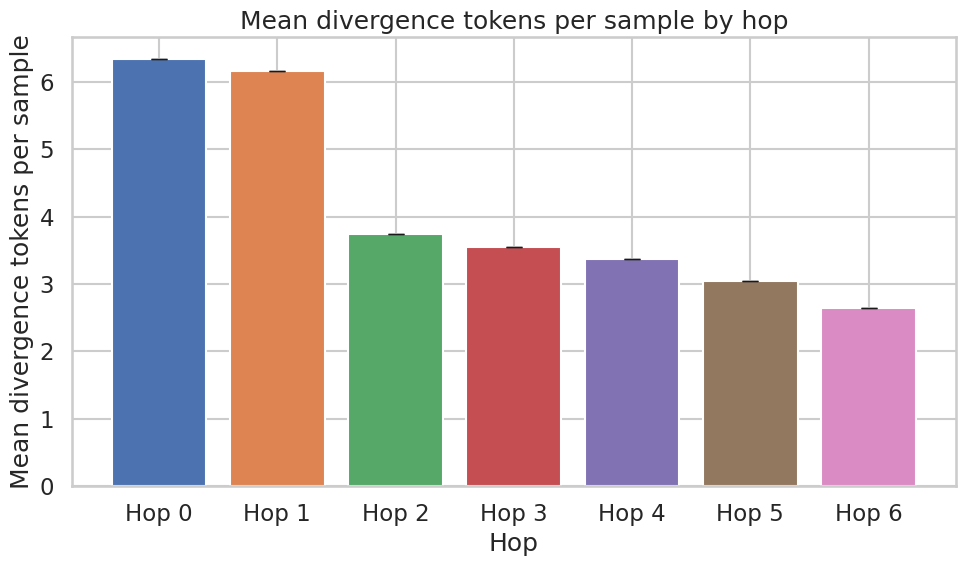

/tmp/ipykernel_31845/2634519054.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x='hop_label', y='n_dpoints', ax=ax, palette='deep')


Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/dpoint_count_boxplot.png
Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/dpoint_count_boxplot.pdf


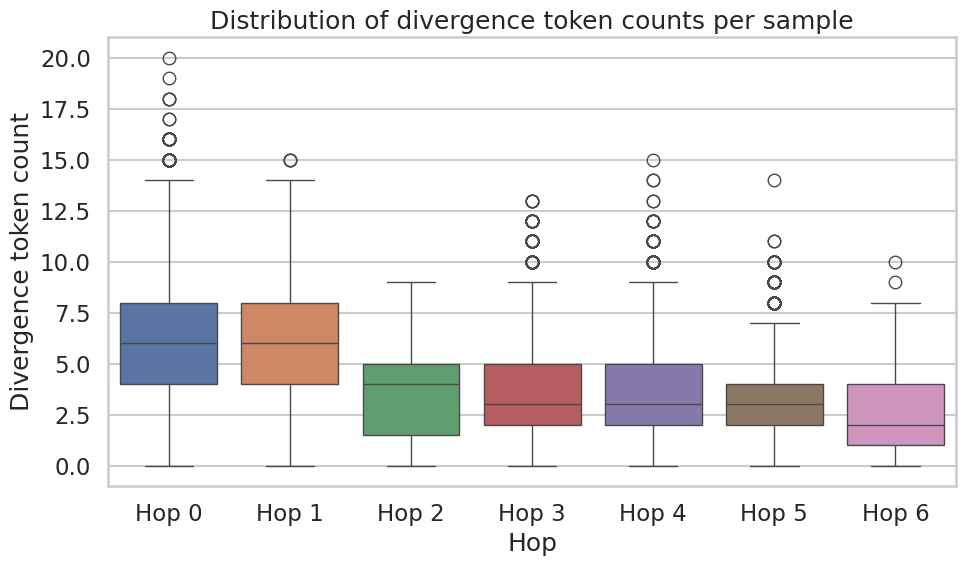

Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/position_histograms_overlaid.png
Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/position_histograms_overlaid.pdf


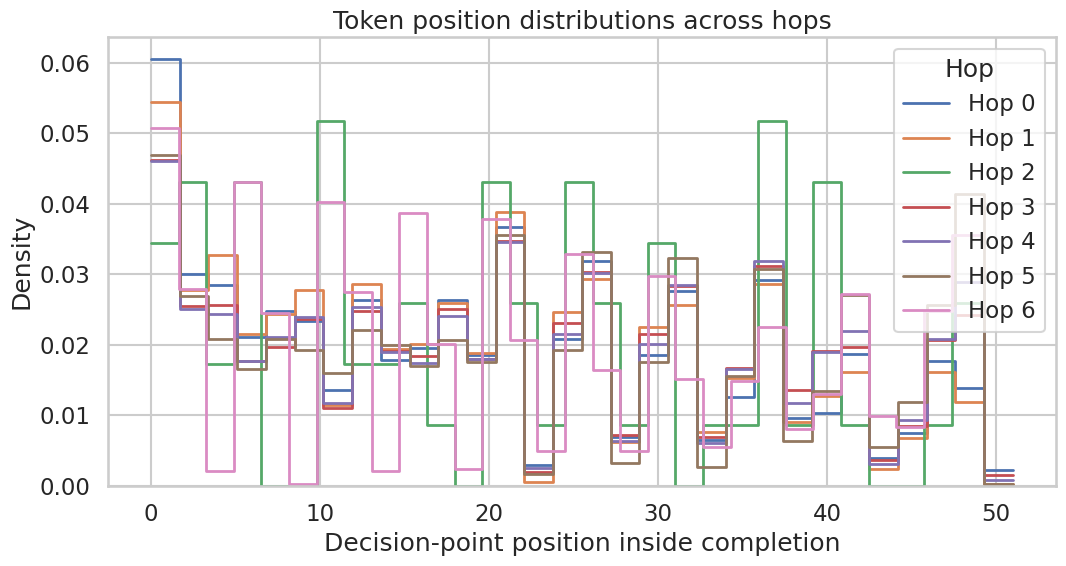

Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/position_cdf_by_hop.png
Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/position_cdf_by_hop.pdf


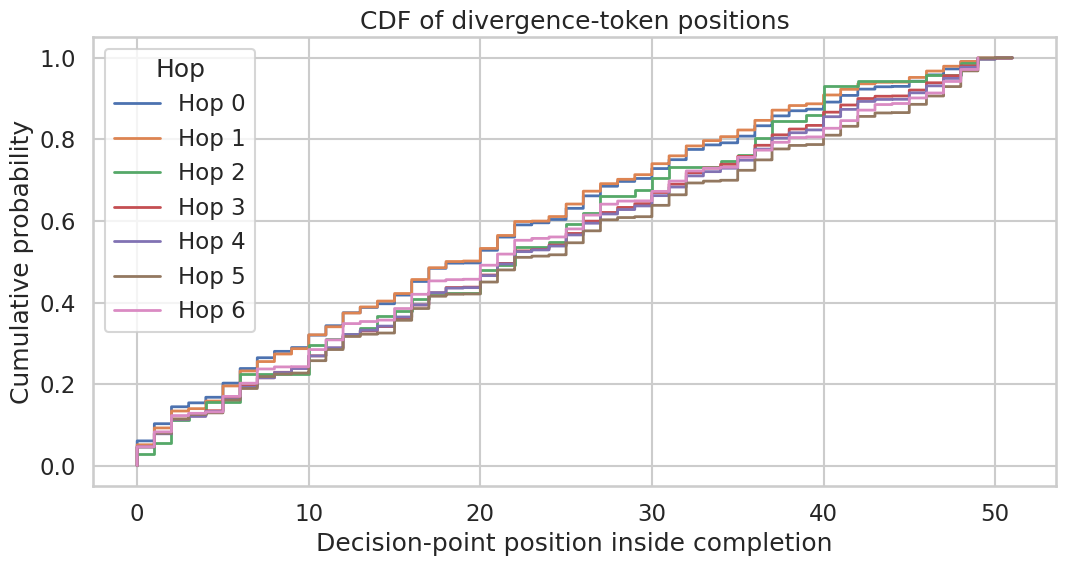

Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/metric_evolution_with_ci.png
Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/metric_evolution_with_ci.pdf


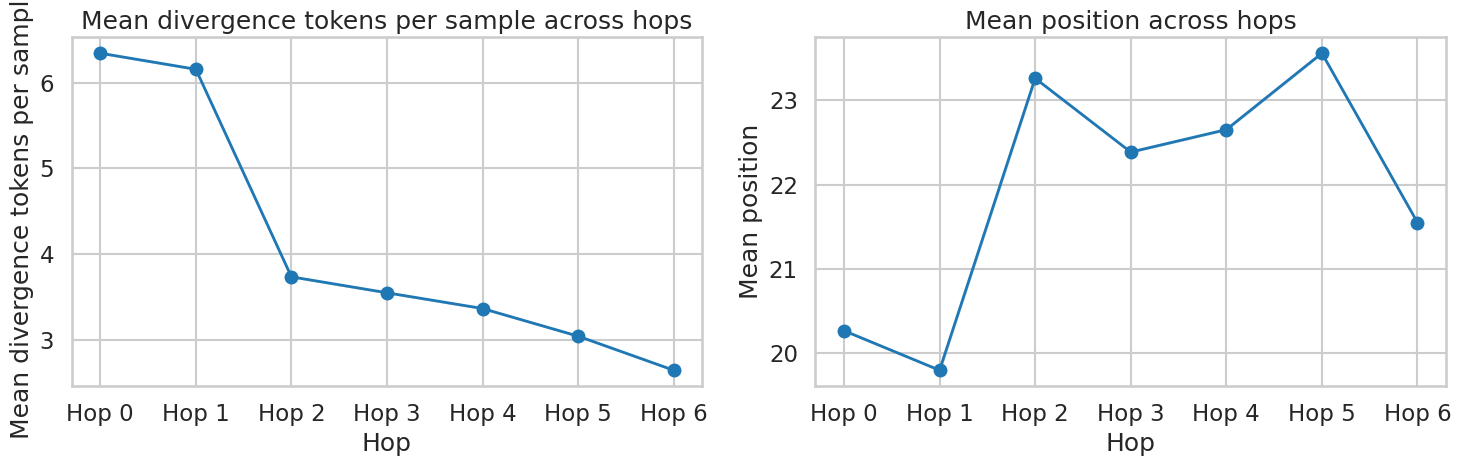

Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/hop_count_correlation_heatmap.png
Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/hop_count_correlation_heatmap.pdf


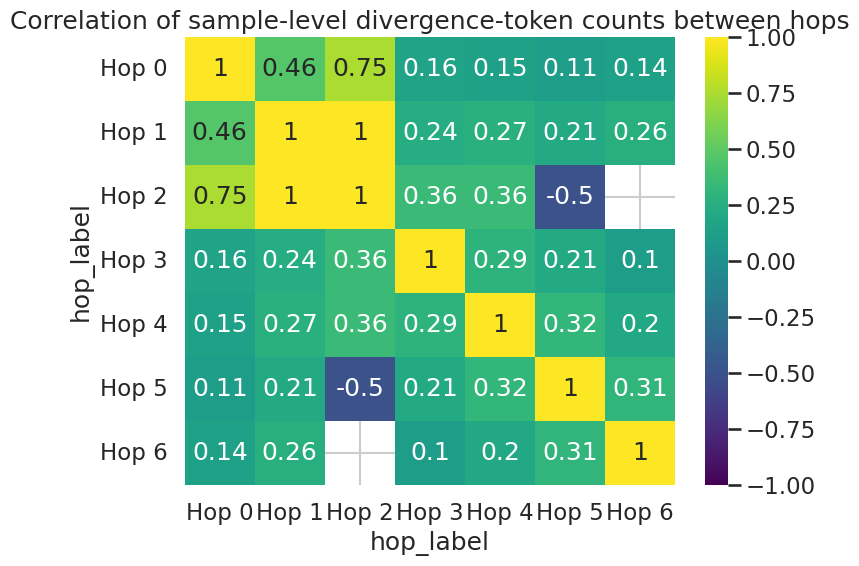

Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/hop0_vs_hop1_scatter.png
Saved figure: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/figures/hop0_vs_hop1_scatter.pdf


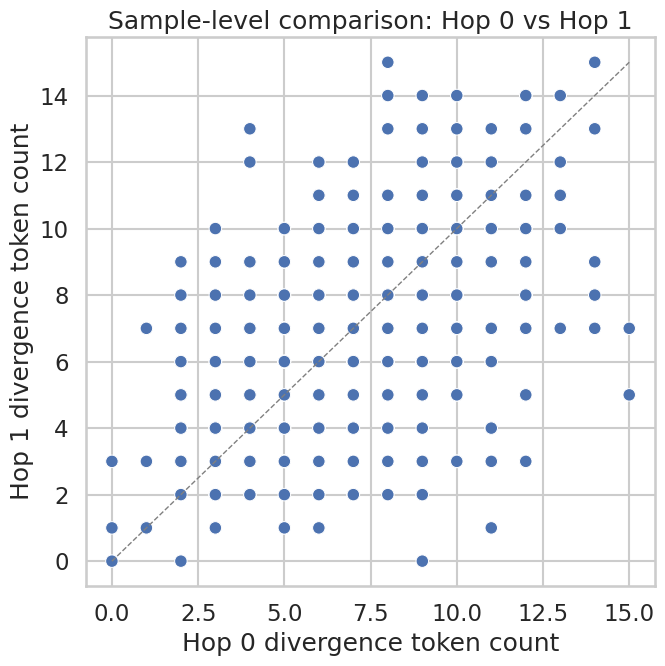

Plot generation complete.


In [8]:
# Visual summaries for token-count and token-position evolution.
if not summary_df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(summary_df))
    y = summary_df['mean_dpoints_per_sample_mean'].values
    yerr = np.vstack([
        y - summary_df['mean_dpoints_per_sample_ci_lower'].values,
        summary_df['mean_dpoints_per_sample_ci_upper'].values - y,
    ])
    ax.bar(summary_df['hop_label'], y, yerr=yerr, capsize=6, color=sns.color_palette('deep', n_colors=len(summary_df)))
    ax.set_title('Mean divergence tokens per sample by hop')
    ax.set_xlabel('Hop')
    ax.set_ylabel('Mean divergence tokens per sample')
    save_figure(fig, 'mean_dpoints_per_sample_by_hop')
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=sample_df, x='hop_label', y='n_dpoints', ax=ax, palette='deep')
    ax.set_title('Distribution of divergence token counts per sample')
    ax.set_xlabel('Hop')
    ax.set_ylabel('Divergence token count')
    save_figure(fig, 'dpoint_count_boxplot')
    plt.show()
    plt.close(fig)

if not position_df.empty:
    fig, ax = plt.subplots(figsize=(11, 6))
    for hop_index, hop in enumerate(HOPS):
        values = position_df.loc[position_df['hop'] == hop, 'position'].dropna().astype(float)
        if values.empty:
            continue
        sns.histplot(values, bins=30, stat='density', element='step', fill=False, ax=ax, label=hop_name(hop), linewidth=2)
    ax.set_title('Token position distributions across hops')
    ax.set_xlabel('Decision-point position inside completion')
    ax.set_ylabel('Density')
    ax.legend(title='Hop')
    save_figure(fig, 'position_histograms_overlaid')
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(11, 6))
    for hop_index, hop in enumerate(HOPS):
        values = np.sort(position_df.loc[position_df['hop'] == hop, 'position'].dropna().astype(float).values)
        if values.size == 0:
            continue
        cdf = np.arange(1, values.size + 1) / values.size
        ax.plot(values, cdf, drawstyle='steps-post', linewidth=2, label=hop_name(hop))
    ax.set_title('CDF of divergence-token positions')
    ax.set_xlabel('Decision-point position inside completion')
    ax.set_ylabel('Cumulative probability')
    ax.legend(title='Hop')
    save_figure(fig, 'position_cdf_by_hop')
    plt.show()
    plt.close(fig)

if not summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    metrics_to_plot = [('mean_dpoints_per_sample', 'Mean divergence tokens per sample'), ('mean_position', 'Mean position')]
    for axis, (metric, ylabel) in zip(axes, metrics_to_plot):
        y = summary_df[f'{metric}_mean'].values
        lower = summary_df[f'{metric}_ci_lower'].values
        upper = summary_df[f'{metric}_ci_upper'].values
        x = np.arange(len(summary_df))
        axis.plot(summary_df['hop_label'], y, marker='o', linewidth=2, color='tab:blue')
        axis.fill_between(summary_df['hop_label'], lower, upper, color='tab:blue', alpha=0.2)
        axis.set_title(ylabel + ' across hops')
        axis.set_xlabel('Hop')
        axis.set_ylabel(ylabel)
    save_figure(fig, 'metric_evolution_with_ci')
    plt.show()
    plt.close(fig)

if not sample_df.empty:
    hop_pivot = sample_df.pivot_table(index=['seed', 'prompt', 'prompt_occurrence'], columns='hop_label', values='n_dpoints', aggfunc='mean')
    if hop_pivot.shape[1] > 1:
        corr_matrix = hop_pivot.corr()
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='viridis', vmin=-1, vmax=1, ax=ax)
        ax.set_title('Correlation of sample-level divergence-token counts between hops')
        save_figure(fig, 'hop_count_correlation_heatmap')
        plt.show()
        plt.close(fig)

if not comparison_df.empty:
    first_pair = comparison_df.loc[comparison_df['left_hop'] == HOPS[0]].copy()
    if not first_pair.empty:
        fig, ax = plt.subplots(figsize=(7, 7))
        sns.scatterplot(data=first_pair, x=f'n_dpoints_0', y=f'n_dpoints_1', hue='seed', palette='deep', ax=ax, legend=False)
        max_value = max(first_pair[f'n_dpoints_0'].max(), first_pair[f'n_dpoints_1'].max())
        ax.plot([0, max_value], [0, max_value], linestyle='--', color='gray', linewidth=1)
        ax.set_title('Sample-level comparison: Hop 0 vs Hop 1')
        ax.set_xlabel('Hop 0 divergence token count')
        ax.set_ylabel('Hop 1 divergence token count')
        save_figure(fig, 'hop0_vs_hop1_scatter')
        plt.show()
        plt.close(fig)

print('Plot generation complete.')

In [9]:
# Correctness-matrix analysis and markdown report export.
report_lines = [
    '# Divergence Token Evolution Summary',
    '',
    f'- Experiment directory: {EXP_DIR.resolve()}',
    f'- Model: {MODEL}',
    f'- Target preference: {TARGET_PREFERENCE}',
    f'- Seeds analyzed: {SEEDS}',
    f'- Hops analyzed: {HOPS}',
]

if summary_df.empty:
    report_lines.extend([
        '',
        'No divergence-token data were loaded, so the notebook could not compute hop-level summaries.',
    ])
else:
    report_lines.extend(['', '## Hop-level summary'])
    for _, row in summary_df.iterrows():
        report_lines.append(
            f"- {row['hop_label']}: mean dpoints/sample = {row['mean_dpoints_per_sample_mean']:.3f} "
            f"[CI {row['mean_dpoints_per_sample_ci_lower']:.3f}, {row['mean_dpoints_per_sample_ci_upper']:.3f}], "
            f"mean position = {row['mean_position_mean']:.3f} [CI {row['mean_position_ci_lower']:.3f}, {row['mean_position_ci_upper']:.3f}]"
        )

    report_lines.extend(['', '## Adjacent-hop changes'])
    for hop_index in range(len(summary_df) - 1):
        left = summary_df.iloc[hop_index]
        right = summary_df.iloc[hop_index + 1]
        dpoints_change = right['mean_dpoints_per_sample_mean'] - left['mean_dpoints_per_sample_mean']
        position_change = right['mean_position_mean'] - left['mean_position_mean']
        dpoints_sig = not ci_overlap(
            {'lower_bound': left['mean_dpoints_per_sample_ci_lower'], 'upper_bound': left['mean_dpoints_per_sample_ci_upper']},
            {'lower_bound': right['mean_dpoints_per_sample_ci_lower'], 'upper_bound': right['mean_dpoints_per_sample_ci_upper']},
        )
        position_sig = not ci_overlap(
            {'lower_bound': left['mean_position_ci_lower'], 'upper_bound': left['mean_position_ci_upper']},
            {'lower_bound': right['mean_position_ci_lower'], 'upper_bound': right['mean_position_ci_upper']},
        )
        report_lines.append(
            f"- {left['hop_label']} -> {right['hop_label']}: delta dpoints/sample = {dpoints_change:+.3f} "
            f"({'non-overlapping CIs' if dpoints_sig else 'overlapping CIs'}), delta mean position = {position_change:+.3f} "
            f"({'non-overlapping CIs' if position_sig else 'overlapping CIs'})"
        )

    if not comparison_df.empty:
        report_lines.extend(['', '## Emergence / disappearance'])
        report_lines.append(f'- Aligned comparisons available: {len(comparison_df)}')
        report_lines.append(f"- Gained divergence tokens: {int(comparison_df['gained_dpoints'].sum())}")
        report_lines.append(f"- Lost divergence tokens: {int(comparison_df['lost_dpoints'].sum())}")
        report_lines.append(f"- Consistent nonzero divergence tokens: {int(comparison_df['consistent_dpoints'].sum())}")

    if not matrix_df.empty:
        report_lines.extend(['', '## Correctness matrices'])
        matrix_summary = matrix_df.groupby(['hop', 'hop_label'], dropna=False).agg(
            mean_target_accuracy=('target_accuracy', 'mean'),
            mean_matrix_density=('matrix_density', 'mean'),
            mean_target_correct_at_dpoints=('target_correct_at_dpoints', 'mean'),
        ).reset_index()
        for _, row in matrix_summary.iterrows():
            report_lines.append(
                f"- {row['hop_label']}: target accuracy = {row['mean_target_accuracy']:.3f}, "
                f"target accuracy at decision points = {row['mean_target_correct_at_dpoints']:.3f}, "
                f"matrix density = {row['mean_matrix_density']:.3f}"
            )

report_path = OUTPUT_DIR / 'analysis_report.md'
report_path.write_text('\n'.join(report_lines) + '\n', encoding='utf-8')
print(f'Saved markdown report to {report_path}')

# Print a compact summary for the notebook output.
display_columns = [c for c in ['hop_label', 'mean_dpoints_per_sample_mean', 'mean_position_mean', 'target_accuracy_mean', 'pct_samples_with_0_mean', 'pct_samples_with_3plus_mean'] if c in summary_df.columns]
if not summary_df.empty and display_columns:
    display(summary_df[display_columns])

if not matrix_df.empty:
    matrix_summary_df = matrix_df.groupby(['hop', 'hop_label', 'hop_index'], dropna=False).agg(
        n_samples=('sample_index', 'count'),
        mean_target_accuracy=('target_accuracy', 'mean'),
        mean_target_correct_at_dpoints=('target_correct_at_dpoints', 'mean'),
        mean_matrix_density=('matrix_density', 'mean'),
    ).reset_index()
    matrix_summary_path = OUTPUT_DIR / 'correctness_matrix_summary.csv'
    matrix_summary_df.to_csv(matrix_summary_path, index=False)
    print(f'Saved correctness-matrix summary to {matrix_summary_path}')

Saved markdown report to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/analysis_report.md


,hop_label,mean_dpoints_per_sample_mean,mean_position_mean,target_accuracy_mean,pct_samples_with_0_mean,pct_samples_with_3plus_mean
0,Hop 0,6.343265,20.263738,0.827845,0.004716,0.911998
1,Hop 1,6.156118,19.793773,0.798004,0.005063,0.916456
2,Hop 2,3.736842,23.262037,0.819978,0.052632,0.631579
3,Hop 3,3.550832,22.385619,0.732384,0.045474,0.658158
4,Hop 4,3.367408,22.652175,0.712455,0.053056,0.626761
5,Hop 5,3.045014,23.560235,0.688637,0.065812,0.568091
6,Hop 6,2.647925,21.548539,0.628893,0.080321,0.483266


Saved correctness-matrix summary to /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/correctness_matrix_summary.csv


## What to Look For

A strengthening divergence-token pattern usually looks like a rise in `mean_dpoints_per_sample`, a larger share of samples in `samples_with_2` or `samples_with_3plus`, and a shift in token positions if the divergence starts earlier or later in the completion.

A weakening pattern looks like the opposite: fewer decision points, more zero-token samples, or a collapse toward later positions / lower target correctness at decision points.

Emergence and disappearance matter at the sample level: samples that move from 0 to >0 decision points suggest new divergence signal, while samples that go from >0 to 0 suggest the training hop has removed that signal.

## Additional Visualization Suite

The next cells add a visualization-focused pass over the same divergence-token tables already loaded above. They reuse `sample_df`, `position_df`, `seed_summary_df`, `summary_df`, and `comparison_df`, so they stay aligned with the raven experiment layout and the existing export directory.


plotly is not installed; Sankey diagrams will be skipped.
Visualization output directory: /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations


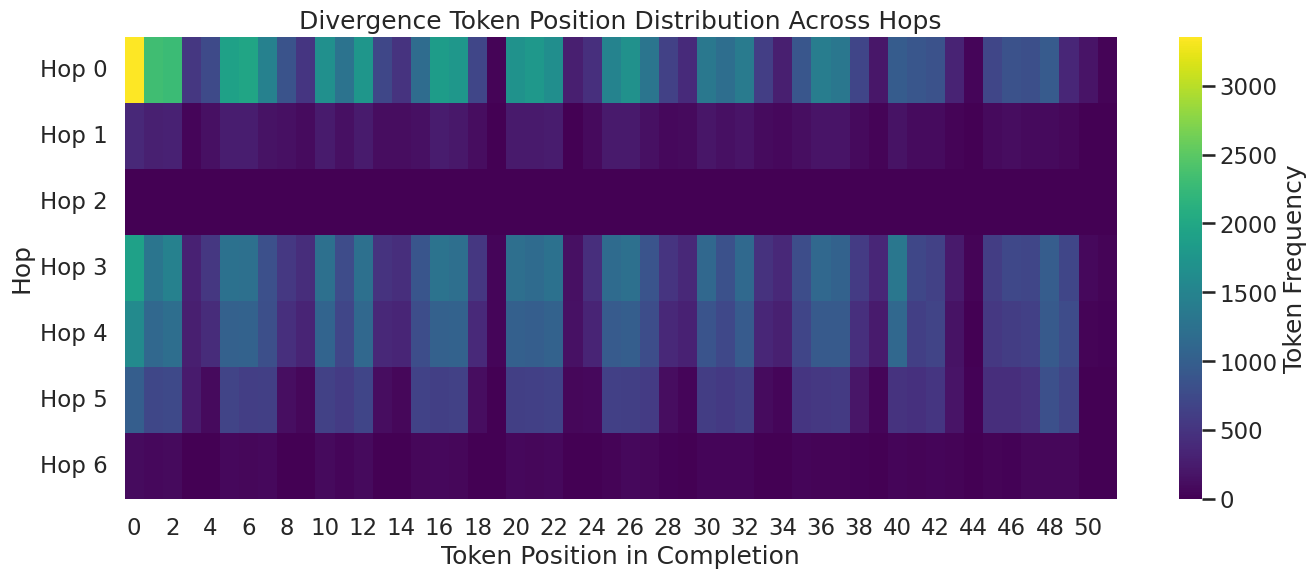

Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/position_heatmap.png


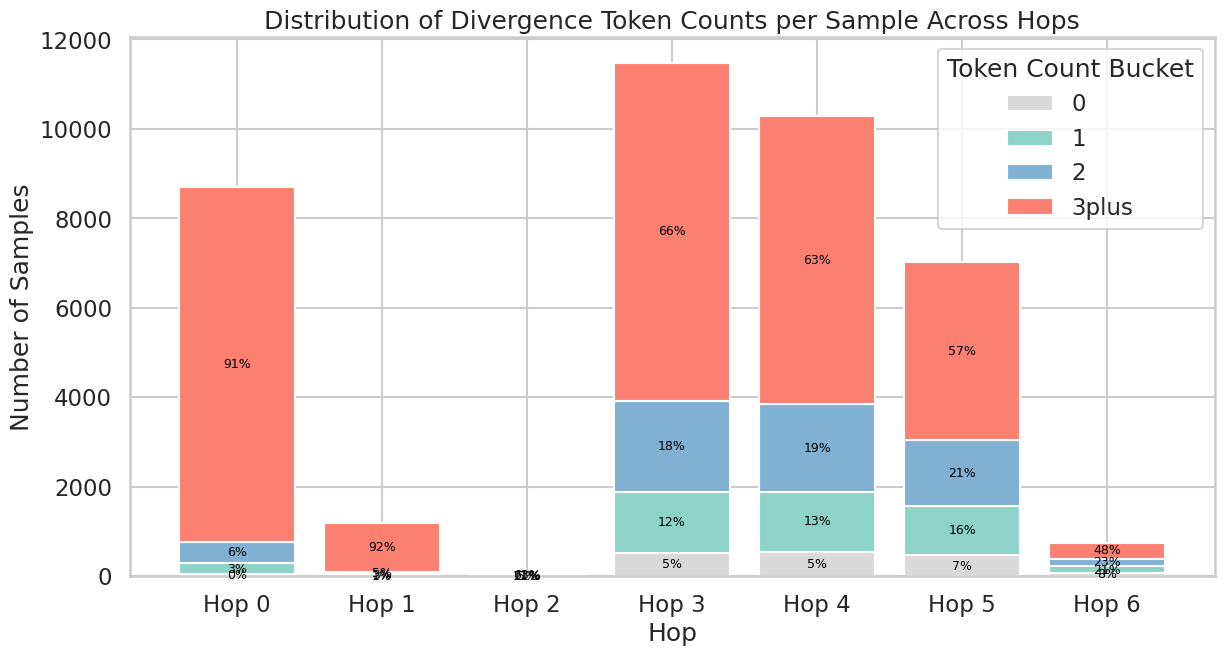

Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/stacked_token_counts.png


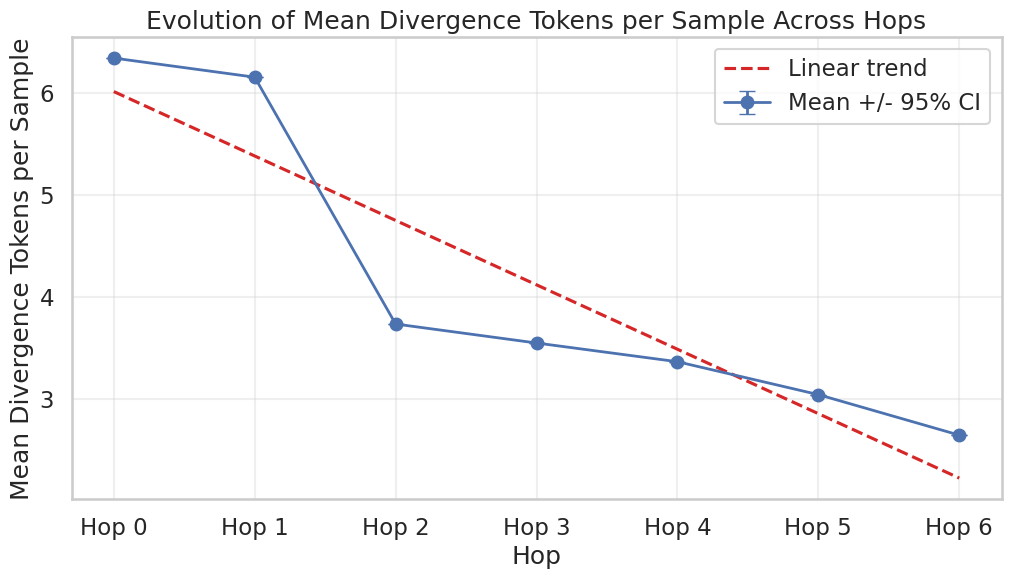

Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/mean_tokens_evolution.png


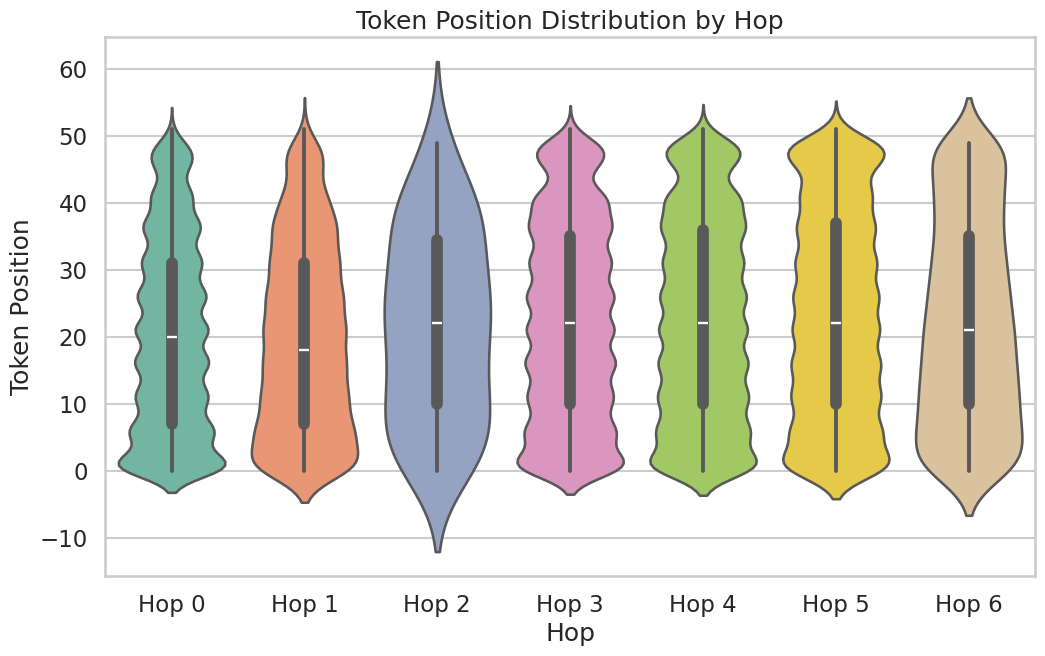

Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/position_violin.png
Skipping Sankey diagrams because plotly is unavailable or transition data are empty.


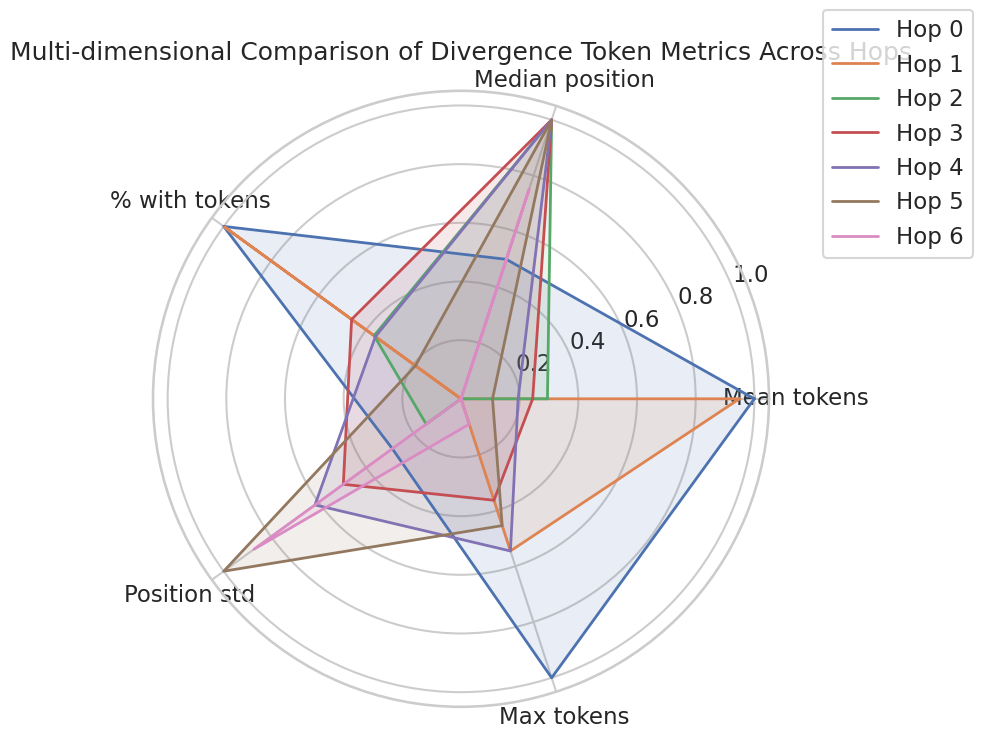

Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/radar_metrics.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/pairplot_metrics.png


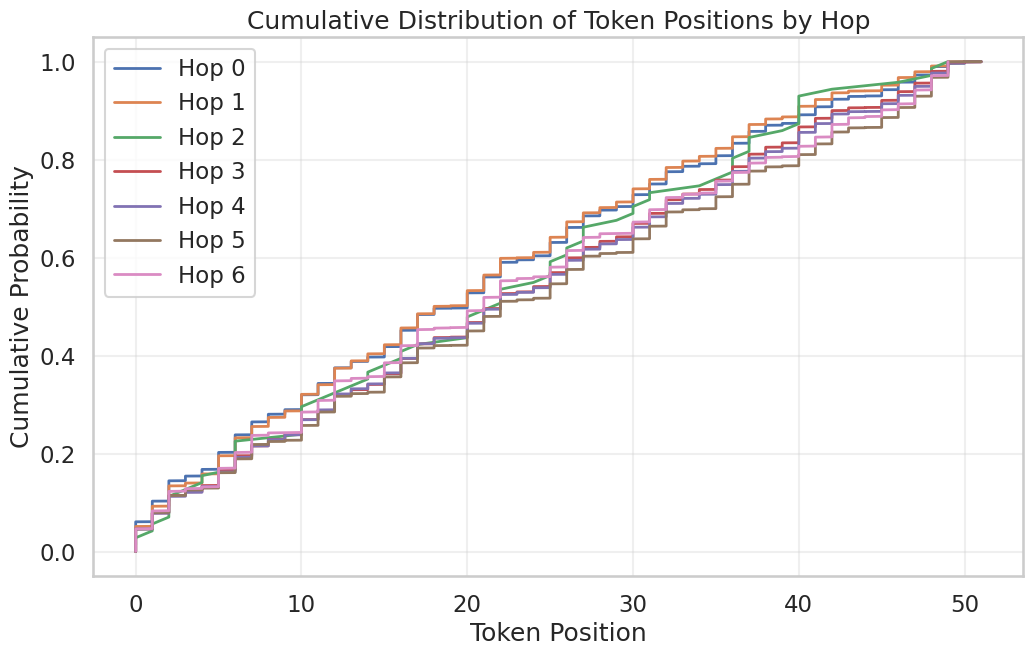

Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/position_cdf.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/box_swarm_positions.png


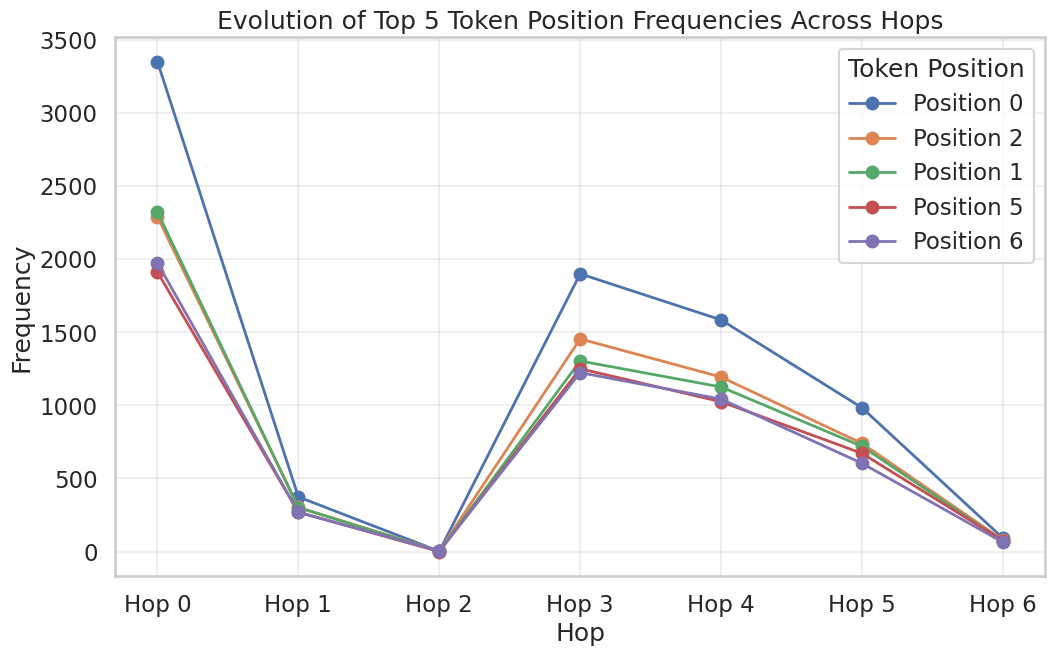

Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/div_points_analysis/divergence_token_analysis/visualizations/top5_position_frequencies.png
Additional visualization suite complete.


In [10]:
import math
import warnings

VIS_DIR = OUTPUT_DIR / 'visualizations'
VIS_DIR.mkdir(parents=True, exist_ok=True)

try:
    import plotly.graph_objects as go
except ImportError:
    go = None
    print('plotly is not installed; Sankey diagrams will be skipped.')

print(f'Visualization output directory: {VIS_DIR}')

if sample_df.empty or position_df.empty:
    print('No divergence-token data loaded, so the visualization suite cannot render plots yet.')
else:
    hop_order = [hop for hop in HOPS if hop in set(sample_df['hop'])]
    hop_labels = [hop_name(hop) for hop in hop_order]
    position_df_vis = position_df.copy()
    position_df_vis['hop_label'] = position_df_vis['hop'].map(hop_name)

    # 1) Position heatmap.
    max_position = int(position_df['position'].max()) if not position_df.empty else 0
    max_position = min(max_position, 80)
    position_matrix = pd.DataFrame(0, index=hop_labels, columns=range(max_position + 1), dtype=float)
    for hop in hop_order:
        hop_positions = position_df.loc[position_df['hop'] == hop, 'position'].astype(int)
        counts = hop_positions.value_counts().sort_index()
        label = hop_name(hop)
        for position, count in counts.items():
            if position <= max_position:
                position_matrix.loc[label, position] = count
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(position_matrix, cmap='viridis', cbar_kws={'label': 'Token Frequency'}, ax=ax)
    ax.set_title('Divergence Token Position Distribution Across Hops')
    ax.set_xlabel('Token Position in Completion')
    ax.set_ylabel('Hop')
    heatmap_path = VIS_DIR / 'position_heatmap.png'
    fig.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved {heatmap_path}')

    # 2) Stacked bar chart of token counts per hop.
    count_buckets = ['0', '1', '2', '3plus']
    bucket_counts = (
        sample_df.assign(bucket=sample_df['n_dpoints'].apply(bucket_count))
        .groupby(['hop', 'bucket'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=hop_order, columns=count_buckets, fill_value=0)
    )
    bucket_percentages = bucket_counts.div(bucket_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    fig, ax = plt.subplots(figsize=(14, 7))
    bottom = np.zeros(len(bucket_counts))
    palette = {'0': '#d9d9d9', '1': '#8dd3c7', '2': '#80b1d3', '3plus': '#fb8072'}
    for bucket in count_buckets:
        values = bucket_counts[bucket].values
        bars = ax.bar(hop_labels, values, bottom=bottom, label=bucket, color=palette[bucket])
        for idx, bar in enumerate(bars):
            pct = bucket_percentages.iloc[idx][bucket] * 100 if bucket_counts.iloc[idx].sum() > 0 else 0
            if bar.get_height() > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[idx] + bar.get_height() / 2,
                    f'{pct:.0f}%',
                    ha='center',
                    va='center',
                    fontsize=9,
                    color='black',
                )
        bottom += values
    ax.set_title('Distribution of Divergence Token Counts per Sample Across Hops')
    ax.set_xlabel('Hop')
    ax.set_ylabel('Number of Samples')
    ax.legend(title='Token Count Bucket')
    stacked_path = VIS_DIR / 'stacked_token_counts.png'
    fig.savefig(stacked_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved {stacked_path}')

    # 3) Mean token count evolution with confidence intervals.
    mean_rows = []
    for hop in hop_order:
        values = seed_summary_df.loc[seed_summary_df['hop'] == hop, 'mean_dpoints_per_sample'].dropna().values
        if len(values) == 0:
            continue
        ci = compute_ci(values)
        mean_rows.append({'hop': hop, 'hop_label': hop_name(hop), 'mean': ci['mean'], 'lower': ci['lower_bound'], 'upper': ci['upper_bound']})
    mean_df = pd.DataFrame(mean_rows)
    if not mean_df.empty:
        x = np.arange(len(mean_df))
        y = mean_df['mean'].values
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.errorbar(mean_df['hop_label'], y, yerr=[y - mean_df['lower'].values, mean_df['upper'].values - y], fmt='o-', capsize=6, linewidth=2, label='Mean +/- 95% CI')
        if len(mean_df) >= 2:
            x_numeric = np.arange(len(mean_df))
            slope, intercept = np.polyfit(x_numeric, y, 1)
            ax.plot(mean_df['hop_label'], intercept + slope * x_numeric, linestyle='--', color='tab:red', label='Linear trend')
        ax.set_title('Evolution of Mean Divergence Tokens per Sample Across Hops')
        ax.set_xlabel('Hop')
        ax.set_ylabel('Mean Divergence Tokens per Sample')
        ax.grid(True, alpha=0.3)
        ax.legend()
        mean_path = VIS_DIR / 'mean_tokens_evolution.png'
        fig.savefig(mean_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f'Saved {mean_path}')

    # 4) Violin plots of token position distributions.
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.violinplot(
        data=position_df_vis,
        x='hop_label',
        y='position',
        order=hop_labels,
        hue='hop_label',
        palette='Set2',
        legend=False,
        inner='box',
        ax=ax,
    )
    ax.set_title('Token Position Distribution by Hop')
    ax.set_xlabel('Hop')
    ax.set_ylabel('Token Position')
    violin_path = VIS_DIR / 'position_violin.png'
    fig.savefig(violin_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved {violin_path}')

    # 5) Sankey diagrams for transitions between adjacent hops.
    if go is not None and not comparison_df.empty:
        sankey_dir = VIS_DIR / 'sankey'
        sankey_dir.mkdir(exist_ok=True)
        categories = ['0', '1', '2', '3plus']
        category_palette = {'0': '#d9d9d9', '1': '#8dd3c7', '2': '#80b1d3', '3plus': '#fb8072'}
        for left_hop, right_hop in zip(hop_order[:-1], hop_order[1:]):
            pair = comparison_df[(comparison_df['left_hop'] == left_hop) & (comparison_df['right_hop'] == right_hop)].copy()
            if pair.empty:
                continue
            pair['left_bucket'] = pair[f'n_dpoints_0'].apply(bucket_count)
            pair['right_bucket'] = pair[f'n_dpoints_1'].apply(bucket_count)
            flow = pair.groupby(['left_bucket', 'right_bucket']).size().reset_index(name='count')
            nodes = [f'{hop_name(left_hop)} {bucket}' for bucket in categories] + [f'{hop_name(right_hop)} {bucket}' for bucket in categories]
            node_index = {name: idx for idx, name in enumerate(nodes)}
            sources = [node_index[f'{hop_name(left_hop)} {row.left_bucket}'] for row in flow.itertuples(index=False)]
            targets = [node_index[f'{hop_name(right_hop)} {row.right_bucket}'] for row in flow.itertuples(index=False)]
            values = [int(row.count) for row in flow.itertuples(index=False)]
            colors = [category_palette[row.right_bucket] for row in flow.itertuples(index=False)]
            sankey = go.Figure(go.Sankey(
                node=dict(label=nodes, pad=18, thickness=18),
                link=dict(source=sources, target=targets, value=values, color=colors),
            ))
            sankey.update_layout(title_text=f'Token Count Transitions Between {hop_name(left_hop)} and {hop_name(right_hop)}', font_size=11)
            sankey_path = sankey_dir / f'{left_hop}_to_{right_hop}_sankey.html'
            sankey.write_html(str(sankey_path))
            print(f'Saved {sankey_path}')
    else:
        print('Skipping Sankey diagrams because plotly is unavailable or transition data are empty.')

    # 6) Radar chart of multi-dimensional metrics.
    radar_metrics = pd.DataFrame({
        'hop': hop_order,
        'hop_label': hop_labels,
        'mean_tokens': [sample_df.loc[sample_df['hop'] == hop, 'n_dpoints'].mean() for hop in hop_order],
        'median_position': [position_df.loc[position_df['hop'] == hop, 'position'].median() for hop in hop_order],
        'pct_with_tokens': [1.0 - sample_df.loc[sample_df['hop'] == hop, 'is_0'].mean() for hop in hop_order],
        'position_std': [position_df.loc[position_df['hop'] == hop, 'position'].std(ddof=1) for hop in hop_order],
        'max_tokens': [sample_df.loc[sample_df['hop'] == hop, 'n_dpoints'].max() for hop in hop_order],
    })
    radar_cols = ['mean_tokens', 'median_position', 'pct_with_tokens', 'position_std', 'max_tokens']
    radar_norm = radar_metrics.copy()
    for col in radar_cols:
        col_min = radar_norm[col].min()
        col_max = radar_norm[col].max()
        radar_norm[col] = 0.0 if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min else (radar_norm[col] - col_min) / (col_max - col_min)
    radar_norm['position_std'] = radar_norm['position_std'].fillna(0.0)
    angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for idx, row in radar_norm.iterrows():
        values = row[radar_cols].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=row['hop_label'])
        ax.fill(angles, values, alpha=0.12)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Mean tokens', 'Median position', '% with tokens', 'Position std', 'Max tokens'])
    ax.set_title('Multi-dimensional Comparison of Divergence Token Metrics Across Hops')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    radar_path = VIS_DIR / 'radar_metrics.png'
    fig.savefig(radar_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    print(f'Saved {radar_path}')

    # 7) Pairplot of token metrics.
    pairplot_df = seed_summary_df.copy()
    pairplot_df['pct_with_tokens'] = 1.0 - pairplot_df['pct_samples_with_0']
    pairplot_df['position_std'] = pairplot_df['mean_position'].map(lambda _: np.nan)
    for (hop, seed), group in sample_df.groupby(['hop', 'seed']):
        positions = position_df.loc[(position_df['hop'] == hop) & (position_df['seed'] == seed), 'position']
        pairplot_df.loc[(pairplot_df['hop'] == hop) & (pairplot_df['seed'] == seed), 'position_std'] = positions.std(ddof=1)
    pairplot_cols = ['mean_dpoints_per_sample', 'median_position', 'pct_with_tokens', 'position_std']
    pairplot_df = pairplot_df[['hop_label'] + pairplot_cols].dropna()
    if not pairplot_df.empty:
        g = sns.pairplot(pairplot_df, vars=pairplot_cols, hue='hop_label', corner=True, diag_kind='hist', plot_kws={'alpha': 0.8, 's': 40})
        g.fig.suptitle('Correlation Matrix of Token Metrics Across Hops', y=1.02)
        pairplot_path = VIS_DIR / 'pairplot_metrics.png'
        g.fig.savefig(pairplot_path, dpi=300, bbox_inches='tight')
        plt.close(g.fig)
        print(f'Saved {pairplot_path}')

    # 8) CDF of token positions.
    fig, ax = plt.subplots(figsize=(12, 7))
    for hop in hop_order:
        positions = np.sort(position_df.loc[position_df['hop'] == hop, 'position'].dropna().astype(float).values)
        if positions.size == 0:
            continue
        cdf = np.arange(1, positions.size + 1) / positions.size
        ax.plot(positions, cdf, linewidth=2, label=hop_name(hop))
    ax.set_title('Cumulative Distribution of Token Positions by Hop')
    ax.set_xlabel('Token Position')
    ax.set_ylabel('Cumulative Probability')
    ax.grid(True, alpha=0.3)
    ax.legend()
    cdf_path = VIS_DIR / 'position_cdf.png'
    fig.savefig(cdf_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved {cdf_path}')

    # 9) Box plot with sampled strip overlay (faster than swarmplot on large datasets).
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.boxplot(
        data=position_df_vis,
        x='hop_label',
        y='position',
        order=hop_labels,
        hue='hop_label',
        palette='Set3',
        legend=False,
        ax=ax,
    )
    overlay_df = position_df_vis[['hop_label', 'position']].dropna()
    max_overlay_points = 4000
    if len(overlay_df) > max_overlay_points:
        overlay_df = overlay_df.sample(n=max_overlay_points, random_state=42)
    sns.stripplot(
        data=overlay_df,
        x='hop_label',
        y='position',
        order=hop_labels,
        color='black',
        alpha=0.25,
        size=2.5,
        jitter=0.25,
        ax=ax,
    )
    ax.set_title('Token Position Distribution with Sampled Individual Points')
    ax.set_xlabel('Hop')
    ax.set_ylabel('Token Position')
    box_swarm_path = VIS_DIR / 'box_swarm_positions.png'
    fig.savefig(box_swarm_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved {box_swarm_path}')

    # 10) Top 5 position time series.
    top_positions = position_df['position'].value_counts().head(5).index.tolist()
    top_position_rows = []
    for hop in hop_order:
        hop_positions = position_df.loc[position_df['hop'] == hop, 'position']
        total = len(hop_positions)
        for position in top_positions:
            count = int((hop_positions == position).sum())
            top_position_rows.append({'hop': hop, 'hop_label': hop_name(hop), 'position': position, 'frequency': count, 'frequency_pct': count / total if total else 0.0})
    top_positions_df = pd.DataFrame(top_position_rows)
    fig, ax = plt.subplots(figsize=(12, 7))
    for position in top_positions:
        subset = top_positions_df[top_positions_df['position'] == position]
        ax.plot(subset['hop_label'], subset['frequency'], marker='o', linewidth=2, label=f'Position {position}')
    ax.set_title('Evolution of Top 5 Token Position Frequencies Across Hops')
    ax.set_xlabel('Hop')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    ax.legend(title='Token Position')
    top5_path = VIS_DIR / 'top5_position_frequencies.png'
    fig.savefig(top5_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved {top5_path}')

print('Additional visualization suite complete.')

In [14]:
    # Find hotspots
    max_per_hop = heatmap_df.max(axis=1)
    hotspot_positions = []
    for i, hop in enumerate(hop_order_heatmap):
        max_val = max_per_hop.iloc[i]
        max_pos = heatmap_df.iloc[i].idxmax()
        hotspot_positions.append((hop, max_pos, max_val))
        print(f"{hop_labels_heatmap[i]:8} | Peak density: position {max_pos:2d} ({max_val:.0f} per 1k samples)")

Hop 0    | Peak density: position  0 (386 per 1k samples)
Hop 1    | Peak density: position  0 (316 per 1k samples)
Hop 2    | Peak density: position  6 (263 per 1k samples)
Hop 3    | Peak density: position  0 (166 per 1k samples)
Hop 4    | Peak density: position  0 (154 per 1k samples)
Hop 5    | Peak density: position  0 (140 per 1k samples)
Hop 6    | Peak density: position  0 (123 per 1k samples)
